# Exercise 12: image recognition

**The goal of exercise 12 is to use deep neural network models, implemented in the Keras python package, to recognize and distinguish between the ten handwritten digits (0-9).**



In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
import os
import numpy as np
import matplotlib.pyplot as plt
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

In [2]:
import utils
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam
from keras import layers
%load_ext autoreload
%autoreload 2
# training parameters
batch_size = 32
epochs = 5
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 



## 12.1
**Change at will and train your DNN by increasing the number of epochs to an adequate value. Try to use at least two other optimizers, different from SGD: watch to accuracy and loss for training and validation data and comment on the performances.**

First I test with few epochs the most convenient optimizer (if it's better with few epochs it's going to be better with more?). The model I am using is a sequential NN with the following architecture:

In [35]:
    model = Sequential()
    # add a dense all-to-all relu layer
    model.add(layers.Dense(400,input_shape=(img_rows*img_cols,), activation='relu'))
    # add a dense all-to-all relu layer
    model.add(layers.Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(layers.Dropout(0.5))
    # soft-max layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.summary()

/home/elisa/miniconda3/envs/thesis/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,110 (1.35 MB)

 Trainable params: 355,110 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
optimizers_to_test = ["sgd","adam","nadam", "adamax","rmsprop"]
histories = []
predictions = []

for opt in optimizers_to_test:
    X_train,Y_train,X_test,Y_test= utils.create_mnist_dataset(img_rows,img_cols,num_classes)
    time,hist,pred = utils.test_DNN(img_rows,img_cols,num_classes,X_train,Y_train,X_test,Y_test,batch_size,epochs,opt,return_pred=True)
    histories.append(hist)
    times.append(time)
    predictions.append(pred)

ValueError: too many values to unpack (expected 4)

In [ ]:
for i,t in enumerate(times:
    print(f'Optimizer {optimizers_to_test[]}')

NameError: name 'histories' is not defined

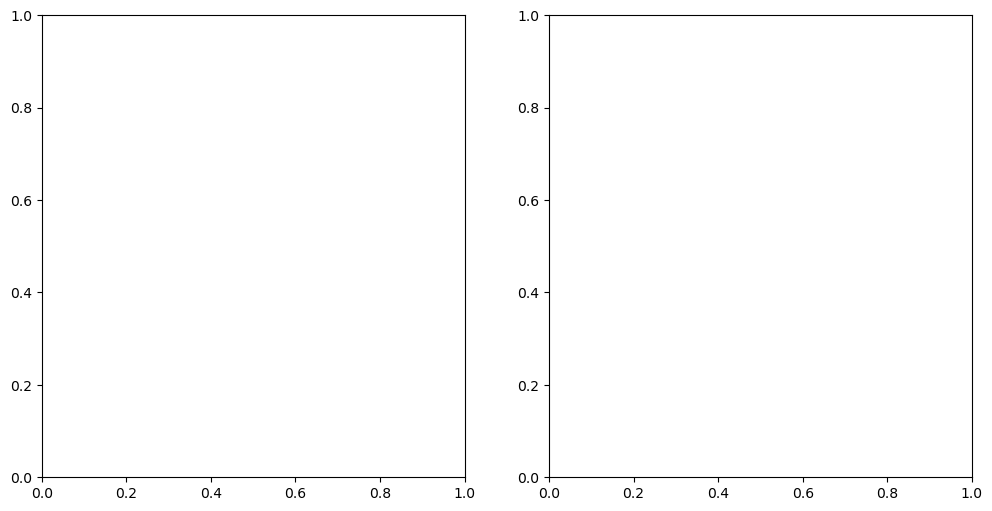

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, len(histories)))
ax[0].set_title ("Accuracy")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("acc")
ax[1].set_title("Loss")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("loss")
for i in range(len(histories)):
    ax[0].plot(histories[i].history["acc"],label = f'{optimizers_to_test[i]} train',c = colors[i])
    ax[0].plot(histories[i].history["val_acc"],label = f'{optimizers_to_test[i]} test',c = colors[i],linestyle = 'dashed')

        
    ax[1].plot(histories[i].history["loss"],label = f'{optimizers_to_test[i]} train',c = colors[i])
    ax[1].plot(histories[i].history["val_loss"],label = f'{optimizers_to_test[i]} test',c = colors[i],linestyle = 'dashed')

plt.legend()
plt.show()

conclusions:
- at first glance best result might be from adam/nadam, but test loss is stagnating: might be overfitting?
- meanwhule adamax looks to be continuously decreasing
- rmsprop is definitely overfitting
- nadam has much longer computation time, so test adam and adamax with a larger number of epochs

In [ ]:
epochs = 50 
eps = np.linspace(1,epochs,epochs)
print(eps)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]


In [6]:
epochs = 50
times,histories,predictions,X_test_list,Y_test_list = [],[],[],[],[]

optimizers_to_test = ['adamax']

for opt in optimizers_to_test:
    X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes)
    time,hist,pred = utils.test_DNN(img_rows,img_cols,num_classes,X_train,Y_train,X_test,Y_test,batch_size,epochs,opt,return_pred=True)
    histories.append(hist)
    times.append(time)
    predictions.append(pred)
    X_test_list.append(X_test)
    Y_test_list.append(Y_test)
    eps = np.linspace(1,epochs,epochs)
    model.save('./OUTPUT/DNN_model.keras')
    np.save("./OUTPUT/DNN_X_train.npy", X_train)
    np.save("./OUTPUT/DNN_Y_train.npy", Y_train)
    np.save("./OUTPUT/DNN_X_test.npy", X_test)
    np.save("./OUTPUT/DNN_Y_test.npy", Y_test)


Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - acc: 0.8066 - loss: 0.6455 - val_acc: 0.9503 - val_loss: 0.1679
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - acc: 0.9393 - loss: 0.2184 - val_acc: 0.9623 - val_loss: 0.1195
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - acc: 0.9555 - loss: 0.1577 - val_acc: 0.9681 - val_loss: 0.1025
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - acc: 0.9650 - loss: 0.1267 - val_acc: 0.9729 - val_loss: 0.0882
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - acc: 0.9712 - loss: 0.1044 - val_acc: 0.9768 - val_loss: 0.0762
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - acc: 0.9749 - loss: 0.0879 - val_acc: 0.9772 - val_loss: 0.0712
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - acc: 0.9788 - loss: 0.0743 - val_acc: 0.9788 - val_loss: 0.0653
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - acc: 0.9817 - loss: 0.0640 - val_acc: 0.9798 - val_loss: 0.0636
Epoch 9/50
1875/1875 ━━━

NameError: name 'model' is not defined

computation times:
[<module 'time' (built-in)>, <module 'time' (built-in)>]
adam took <module 'time' (built-in)> seconds
adamax took <module 'time' (built-in)> seconds


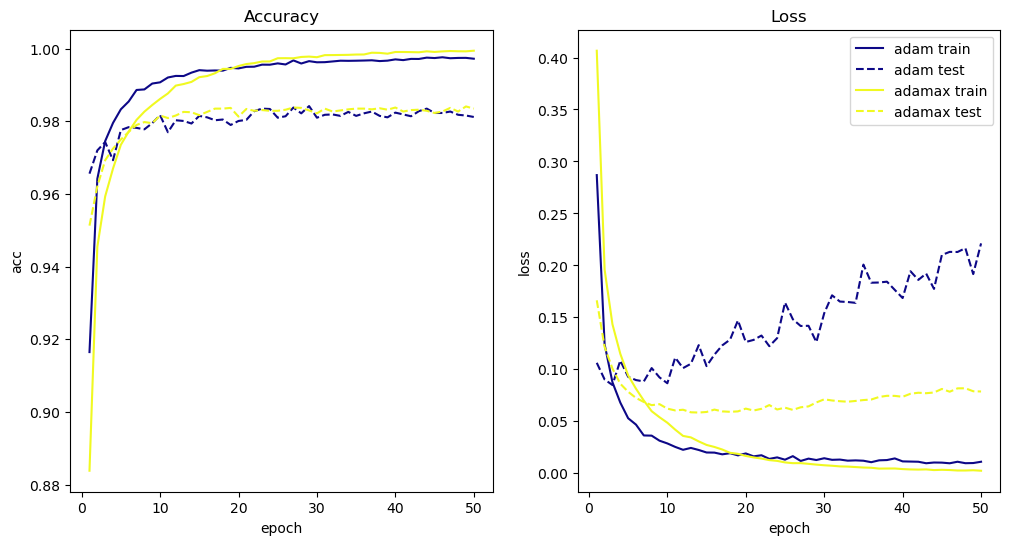

In [ ]:
import pandas as pd
fig,ax = plt.subplots(1,2,figsize=(12,6))
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, len(histories)))
ax[0].set_title ("Accuracy")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("acc")
ax[1].set_title("Loss")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("loss")
print('computation times:')
print(times)
for i,t in enumerate(times):
    print(f'{optimizers_to_test[i]} took {t} seconds')

for i in range(len(histories)):

    df = pd.read_csv(f"./OUTPUT/{optimizers_to_test[i]}_DNN_test.csv",sep = '\t')
    ax[0].plot(df['epoch'],df["acc"],label = f'{optimizers_to_test[i]} train',c = colors[i])
    ax[0].plot(df['epoch'],df["val_acc"],label = f'{optimizers_to_test[i]} test',c = colors[i],linestyle = 'dashed')

        
    ax[1].plot(df['epoch'],df["loss"],label = f'{optimizers_to_test[i]} train',c = colors[i])
    ax[1].plot(df['epoch'],df["val_loss"],label = f'{optimizers_to_test[i]} test',c = colors[i],linestyle = 'dashed')

plt.legend()
plt.show()

adam test loss increases a lot: sign of overfitting?
probably adamax is a better choice even though it converges less rapidly

In [ ]:
for j in range(len(predictions)):

    X_test = X_test_list[j].reshape(X_test_list[j].shape[0], img_rows, img_cols,1)

    plt.figure(figsize=(15, 15)) 
    for i in range(10):    
        ax = plt.subplot(2, 10, i + 1)    
        plt.imshow(X_test[i, :, :, 0], cmap='gray')    
        plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[j]), np.argmax(predictions[j])))    
        plt.axis('off') 
    plt.show()

adamax seems more stable

In [ ]:

def create_CNN():
    # instantiate model
    model = Sequential()
    # add first convolutional layer with 10 filters (dimensionality of output space)
    model.add(Conv2D(10, kernel_size=(5, 5),
                     activation='relu',
                     input_shape=input_shape))
    
    model.add(Conv2D(10, kernel_size=(5, 5),
                     activation='relu',
                     input_shape=input_shape)) 
    #
    # ADD HERE SOME OTHER LAYERS AT YOUR WILL, FOR EXAMPLE SOME: Dropout, 2D pooling, 2D convolutional etc. ... 
    # remember to move towards a standard flat layer in the final part of your DNN,
    # and that we need a soft-max layer with num_classes=10 possible outputs
    #
    
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer='SGD',
                  metrics=['acc'])
    return model

## 12.2

**Change the architecture of your DNN using convolutional layers. Use `Conv2D`, `MaxPooling2D`, `Dropout`, but also do not forget `Flatten`, a standard `Dense` layer and `soft-max` in the end.**

try 3 models:
- a simple one with just one convolution and one max pooling
- intermediate one with 2 conv, 2 max pooling and dropout
- most complex with additional dense layer and intermediate dropout

In [ ]:
#model 1
from keras import layers
models = []
X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes,NNtype='CNN')
model1 = Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(num_classes, activation="softmax"),
    ]
)
model1.summary()
model1.compile(loss=keras.losses.categorical_crossentropy,
                optimizer='Adamax',metrics=['accuracy'])
models.append(model1)

model2 = Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3,3), activation="relu",padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2),strides=2),
        layers.Conv2D(64, kernel_size=(3,3), activation="relu",padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2),strides=2),
        layers.Flatten(),
        layers.Dense(128,activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ]
)
model2.summary()
model2.compile(loss=keras.losses.categorical_crossentropy,
                optimizer='Adamax',metrics=['accuracy'])
models.append(model2)

model3 = Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3,3), activation="relu",padding='same'),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu",padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3,3), activation="relu",padding='same'),
        layers.Conv2D(128, kernel_size=(3,3), activation="relu",padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(128,activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)
model3.summary()
model3.compile(loss=keras.losses.categorical_crossentropy,
                optimizer='Adamax',metrics=['accuracy'])
models.append(model3)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 933,834 (3.56 MB)

 Trainable params: 933,834 (3.56 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
eps = np.linspace(0,epochs-1,epochs)
print(eps)

[0. 1. 2. 3. 4.]


In [ ]:
histories = []
epochs=5
batch_size=32  
import time
for i,model in enumerate(models):
    t0=time.time()
    X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes,NNtype='CNN')

    model.compile(loss=keras.losses.categorical_crossentropy,
                optimizer='Adamax',metrics=['acc'])

    hist = model.fit(X_train, Y_train,
        batch_size=batch_size,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, Y_test))
    t1=time.time()
    histories.append(hist)
    eps = np.linspace(0,epochs-1,epochs)
    print(model.metrics_names)
    score= model.evaluate(X_test, Y_test,verbose=1)
    with open(f"./OUTPUT/CNN_test_model{i}.csv","w") as out:
        out.write(f'time\t{t1-t0}\n')
        out.write(f'test loss:\t{score[0]}\n')
        out.write(f'test accuracy:\t{score[1]}\n')
        out.write("epoch\tloss\tval_loss\tacc\tval_acc\n")

        for i in range(len(hist.history['loss'])):
            out.write(f"{eps[i]}\t{hist.history['loss'][i]}\t{hist.history['val_loss'][i]}\t{hist.history['acc'][i]}\t{hist.history['val_acc'][i]}\n")
    
    

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 28ms/step - acc: 0.8469 - loss: 3.3064 - val_acc: 0.9516 - val_loss: 0.2967
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - acc: 0.9581 - loss: 0.2490 - val_acc: 0.9691 - val_loss: 0.1364
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - acc: 0.9747 - loss: 0.1045 - val_acc: 0.9737 - val_loss: 0.1140
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - acc: 0.9843 - loss: 0.0579 - val_acc: 0.9748 - val_loss: 0.1058
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - acc: 0.9896 - loss: 0.0375 - val_acc: 0.9774 - val_loss: 0.1033
['loss', 'compile_metrics']
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc: 0.9734 - loss: 0.1253
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 113s 58ms/step - acc: 0.8042 - loss: 1.9145 - val_acc: 0.9741 - val_loss: 0.0878
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 114s 61ms/step - acc: 0.9566 - loss: 0.1463 - val_acc: 0.9821 - val_loss: 0.0563
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 129s 69ms/s

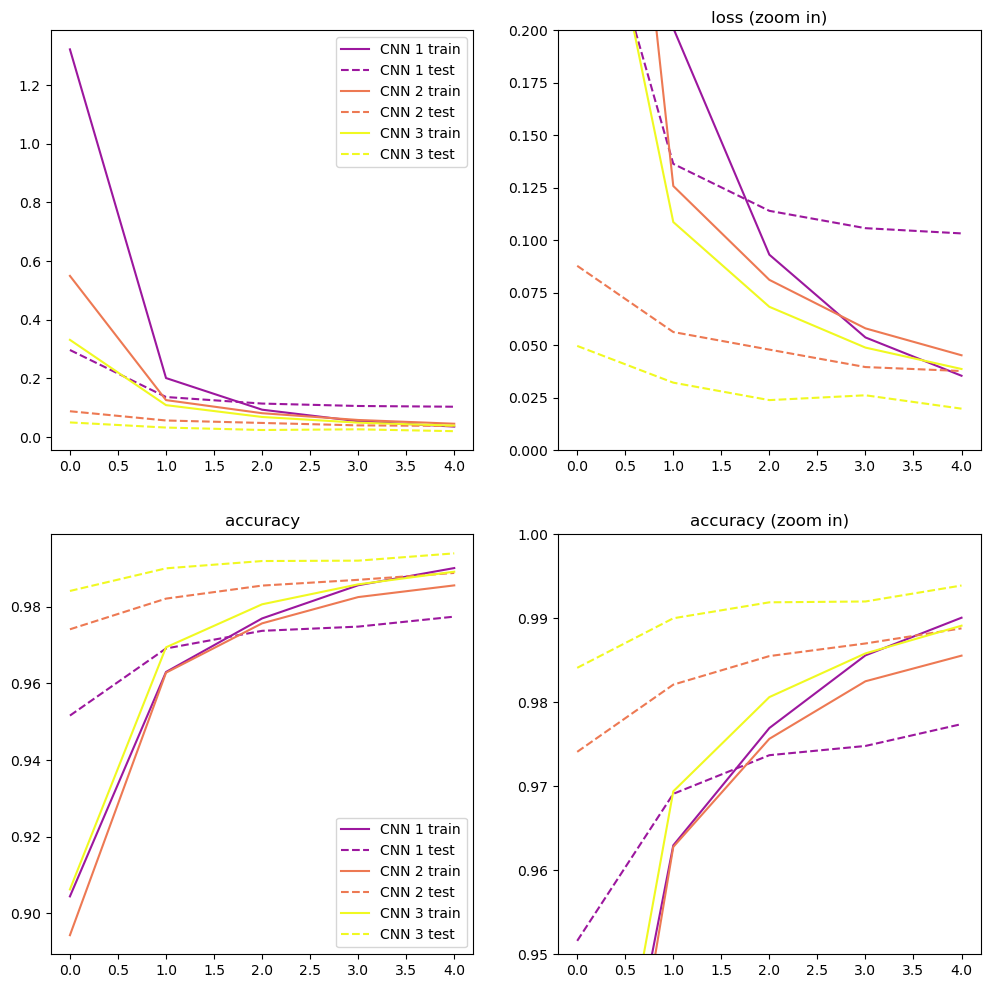

In [ ]:
import pandas as pd
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 4))
fig,ax = plt.subplots(2,2,figsize=(12,12))
#test scores=[]
ax[1,0].set_title('accuracy')
for i in range(3):
    #test_scores.append(models[i].evaluate((X_test, Y_test)))
    df1= pd.read_csv(f'./OUTPUT/CNN_test_model{i}.csv', sep='\t',skiprows=3)

    ax[0,0].plot(df1['epoch'],df1['loss'],label=f'CNN {i+1} train',c=colors[i+1])
    ax[0,0].plot(df1['epoch'],df1['val_loss'],label=f'CNN {i+1} test',linestyle='dashed',c=colors[i+1])
    ax[1,0].plot(df1['epoch'],df1['acc'],label=f'CNN {i+1} train',c=colors[i+1])
    ax[1,0].plot(df1['epoch'],df1['val_acc'],label=f'CNN {i+1} test',linestyle='dashed',c=colors[i+1])


for i in range(3):
    df1= pd.read_csv(f'./OUTPUT/CNN_test_model{i}.csv',sep='\t',skiprows=3)
    ax[0,1].plot(df1['epoch'],df1['loss'],label=f'CNN {i+1} train',c=colors[i+1])
    ax[0,1].plot(df1['epoch'],df1['val_loss'],label=f'CNN {i+1} test',linestyle='dashed',c=colors[i+1])
    ax[1,1].plot(df1['epoch'],df1['acc'],label=f'CNN {i+1} train',c=colors[i+1])
    ax[1,1].plot(df1['epoch'],df1['val_acc'],label=f'CNN {i+1} test',linestyle='dashed',c=colors[i+1])
ax[0,1].set_ylim(0,0.2)
ax[1,1].set_ylim(0.95,1)
ax[0,1].set_title('loss (zoom in)')
ax[0,0].legend() 
ax[1,1].set_title('accuracy (zoom in)')
ax[1,0].legend()

#with open('./OUTPUT/CNN_test_scores.csv','w') as out:
   # out.write('\tloss\tacc\n')
    #for k in range (3):
      #  out.write(f'model{k}\t{test_scores[k][0]}\t{test_scores[k][1]}')

The final accuracies for the 3 tested CNNs are, in order, around 97%,98% and 99%, which are already very good for only 5 epochs. From the plots above we can see that whilethere is a significant improvement between the simplest architecture and the other two, the difference between the latter is not as important. For this reason I am choosing model 2 as my CNN architecture, since model3 takes double the time and only improves the performance a little, which wouldn't be significant anyway for a higher number of epochs

In [ ]:
import time
X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes,NNtype='CNN')
final_model = Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3,3), activation="relu",padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2),strides=2),
        layers.Conv2D(64, kernel_size=(3,3), activation="relu",padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2),strides=2),
        layers.Flatten(),
        layers.Dense(128,activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

epochs=50
batch_size=32 
final_model.compile(loss=keras.losses.categorical_crossentropy,
                optimizer='Adamax',metrics=['acc'])
t0=time.time()
hist = final_model.fit(X_train, Y_train,
        batch_size=batch_size,
        epochs=epochs,
        verbose=0,
        validation_data=(X_test, Y_test))
t1=time.time()

score= final_model.evaluate(X_test, Y_test,verbose=1)
print(f'time\t{t1-t0}')
print(f'test loss:\t{score[0]}')
print(f'test accuracy:\t{score[1]}')

eps = np.linspace(0,epochs-1,epochs)
with open(f"./OUTPUT/CNN_final_metrics.csv","w") as out:
    out.write(f'time\t{t1-t0}\n')
    out.write(f'test loss:\t{score[0]}\n')
    out.write(f'test accuracy:\t{score[1]}\n')
    out.write("epoch\tloss\tval_loss\tacc\tval_acc\n")
    for i in range(len(hist.history['loss'])):
        out.write(f"{eps[i]}\t{hist.history['loss'][i]}\t{hist.history['val_loss'][i]}\t{hist.history['acc'][i]}\t{hist.history['val_acc'][i]}\n")


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - acc: 0.9909 - loss: 0.0649
time	4290.983618736267
test loss:	0.05300386995077133
test accuracy:	0.9922999739646912


In [ ]:
final_model.save('./OUTPUT/final_model.keras')
np.save("./OUTPUT/final_X_train.npy", X_train)
np.save("./OUTPUT/final_Y_train.npy", Y_train)
np.save("./OUTPUT/final_X_test.npy", X_test)
np.save("./OUTPUT/final_Y_test.npy", Y_test)


Text(0.5, 1.0, 'Accuracy')

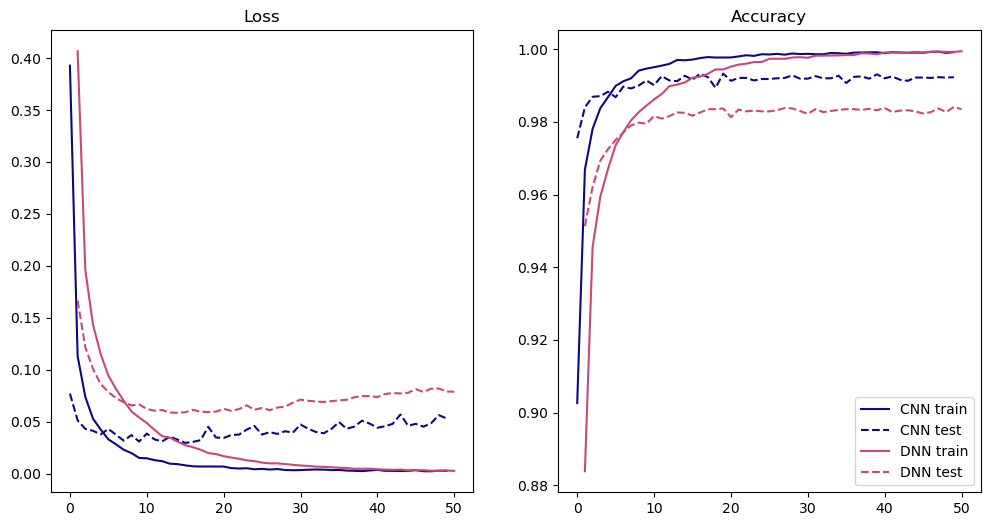

In [ ]:
#comparison with DNN
dnn_df = pd.read_csv("./OUTPUT/adamax_DNN_test.csv",sep='\t')
fig,ax = plt.subplots(1,2,figsize=(12,6))
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 3))

ax[0].plot(hist.history['loss'],c=colors[0],label = 'CNN train')
ax[0].plot(hist.history['val_loss'],c=colors[0],linestyle='dashed',label = 'CNN test')
ax[0].plot(dnn_df['epoch'],dnn_df['loss'],c=colors[1],label = 'DNN train')
ax[0].plot(dnn_df['epoch'],dnn_df['val_loss'],c=colors[1],linestyle='dashed',label = 'DNN test')

ax[1].plot(hist.history['acc'],c=colors[0],label = 'CNN train')
ax[1].plot(hist.history['val_acc'],c=colors[0],linestyle='dashed',label = 'CNN test')
ax[1].plot(dnn_df['epoch'],dnn_df['acc'],c=colors[1],label = 'DNN train')
ax[1].plot(dnn_df['epoch'],dnn_df['val_acc'],c=colors[1],linestyle='dashed',label = 'DNN test')
plt.legend()
ax[0].set_title('Loss')
ax[1].set_title('Accuracy')

CNN convergennce is faster and test loss/accuracy is better

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


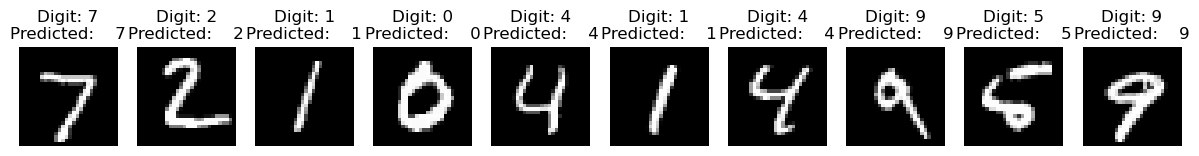

In [41]:
predictions = final_model.predict(X_test)
plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

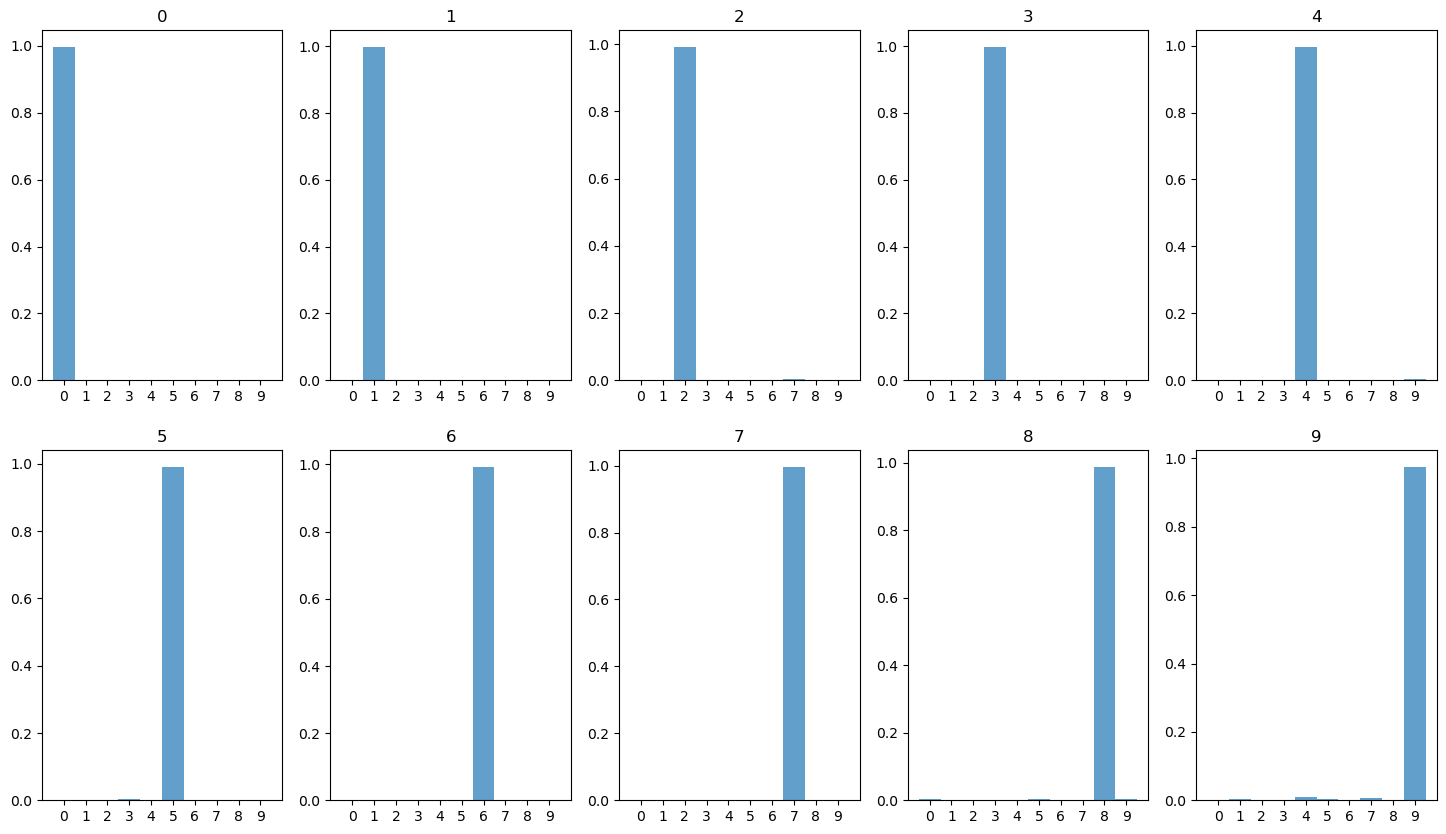

In [72]:
bins=np.linspace(-0.5,9.5,11)
fig,ax = plt.subplots (2,5,figsize=(18,10))
ax=ax.flatten()
for j in range(10):
    mask = Y_test[:,j]==1
    y_pred = np.argmax(predictions[mask],axis=1)
    ax[j].hist(y_pred,bins=bins,density=True,alpha=0.7)
    ax[j].set_title(j)
    ax[j].set_xticks(range(10))

    

In [6]:
from PIL import Image
import os
import numpy as np

digit_filename = "./digits/1tidi.jpeg"
digit_in = Image.open(digit_filename).convert('L')
ydim, xdim = digit_in.size
print("Image size: "+str(xdim)+"x"+str(ydim))
pix=digit_in.load();
data = np.zeros((xdim, ydim))
for j in range(ydim):
 for j in range(ydim):
    for i in range(xdim):
        data[i,j]=pix[j,i]

data /= 255

data=data.reshape(1,xdim,ydim,1)
print(data.shape)
pred= final_model.predict(data)
print(pred)
data = data.reshape(xdim,ydim)
fi,ax=plt.subplots(1,2,figsize=(12,9))
  
ax[0].imshow(data, cmap='gray')    
ax[0].set_title("Digit predicted:    {}".format(np.argmax(pred)))
ax[0].axis('off') 
bins=np.linspace(0,10,10)
ax[1].scatter(bins,pred)


Image size: 28x28
(1, 28, 28, 1)


NameError: name 'final_model' is not defined

In [4]:
from PIL import Image
import os

digit_filename = "./digits/1tidi.jpeg"
digit_in = Image.open(digit_filename).convert('L')
ydim, xdim = digit_in.size
print("Image size: "+str(xdim)+"x"+str(ydim))
pix=digit_in.load();
data = np.zeros((xdim, ydim))
for j in range(ydim):
 for j in range(ydim):
    for i in range(xdim):
        data[i,j]=pix[j,i]

data /= 255
print(X_test.shape[0])
data=data.reshape(1,xdim,ydim,1)
print(data.shape)
pred= final_model.predict(data)
print(pred)
data = data.reshape(xdim,ydim)
fi,ax=plt.subplots(1,2,figsize=(12,9))
  
ax[0].imshow(data, cmap='gray')    
ax[0].set_title("Digit predicted:    {}".format(np.argmax(pred)))
ax[0].axis('off') 
bins=np.linspace(0,10,10)
ax[1].scatter(bins,pred)

Image size: 28x28


NameError: name 'np' is not defined

Image size: 28x28
10000
(1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


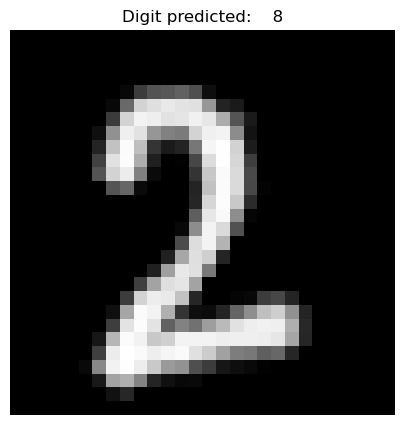

In [93]:
from PIL import Image
import os

digit_filename = "./digits/two.png"
digit_in = Image.open(digit_filename).convert('L')
ydim, xdim = digit_in.size
print("Image size: "+str(xdim)+"x"+str(ydim))
pix=digit_in.load();
data2 = np.zeros((xdim, ydim))
for j in range(ydim):
 for j in range(ydim):
    for i in range(xdim):
        data2[i,j]=pix[j,i]

data2 /= 255
print(X_test.shape[0])
data2=data2.reshape(1,xdim,ydim,1)
print(data2.shape)
pred2= final_model.predict(data2)
data2 = data2.reshape(xdim,ydim)

plt.figure(figsize=(5, 5))  
plt.imshow(data, cmap='gray')    
plt.title("Digit predicted:    {}".format(np.argmax(pred2)))
plt.axis('off') 
plt.show()